In [13]:
""" Problem 8.2.5 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, log10, sqrt
from control import margin

In [15]:
# wp = 90
# Hp = .8
# ws = 220
# Hs = .1

# wc = 100 #guess this

# wp = wp/wc
# ws = ws/wc

# Hp2 = (Hp)**2

# np = log10(1/Hp2 - 1)/(2*log10(wp))
# print('np =', np)

# Hs2 = (Hs)**2

# ns = log10(1/Hs2 - 1)/(2*log10(ws))
# print('ns =', ns)

<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_50316\1648137969.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


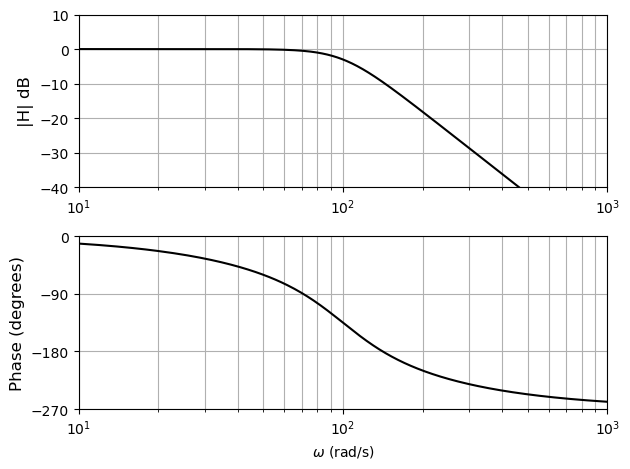

In [19]:
a = 100
n3 = [0,0,0,a]
da = [1,a]
db = [1/(a**2),1/a,1]
d3 = np.convolve(da,db)

num = n3
den = d3

w = np.linspace(10,1000,1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ 10, 1e3, -40, 10])
plt.ylabel('|H| dB',size = 12)
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ 10, 1e3, -270, 0])
plt.yticks([-270,-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.grid(which='both')
plt.tight_layout()
plt.show()